In [16]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine("postgresql://gabi:honzajenejlepsi@[2a01:4f8:1c1f:85ec::1]:5432/postgres")

query = """
SELECT 
    p.product_name,
    SUM(oi.quantity) AS total_sold
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
GROUP BY p.product_id, p.product_name
ORDER BY total_sold DESC;
"""

df = pd.read_sql(query, engine)
df.head()



,product_name,total_sold
0,Protein Powder Vanilla,2
1,Running Shoes X,2
2,Yoga Mat Pro,2
3,Smartwatch Fit,1
4,Wireless Headphones,1


## Top-selling product

C:\Users\gabca\AppData\Local\Temp\ipykernel_35064\709407093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="total_sold", y="product_name", palette="Blues_r")


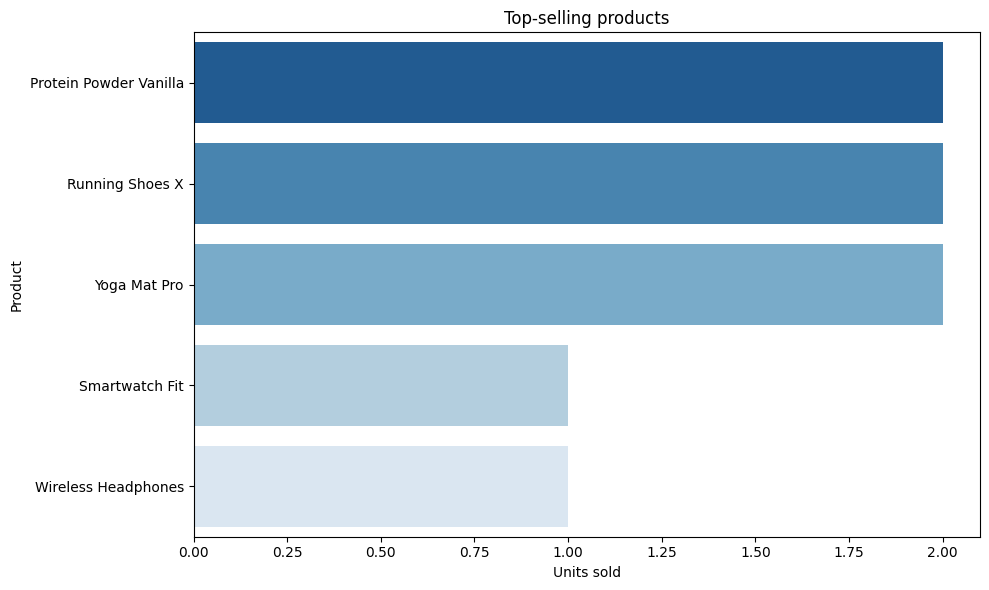

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="total_sold", y="product_name", palette="Blues_r")
plt.title("Top-selling products")
plt.xlabel("Units sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#### Visualization: Top-selling products
This chart shows which products were sold most frequently based on quantity.

## Revenue by customer

In [22]:
query = """
select c.customer_id, c.first_name, c.last_name, sum(oi.quantity*oi.unit_price) as customer_revenue
from customers as c
join orders as o on c.customer_id = o.customer_id
join order_items as oi on o.order_id = oi.order_id
group by c.customer_id
order by c.customer_id asc
;
"""

df = pd.read_sql(query, engine)
df.head()

,customer_id,first_name,last_name,customer_revenue
0,1,Anna,Nováková,6560.0
1,2,Petr,Svoboda,2490.0
2,3,Lucie,Dvořáková,1590.0
3,4,Martin,Kučera,3780.0


C:\Users\gabca\AppData\Local\Temp\ipykernel_35064\703812835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="customer_revenue", y="full_name", palette="Blues_r")


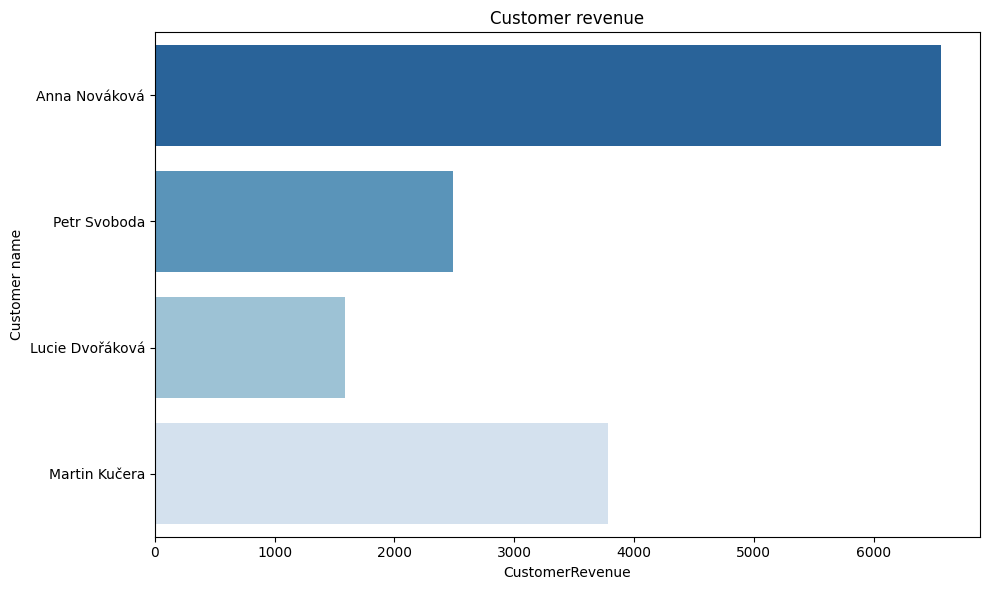

In [25]:
df['full_name'] = df['first_name'] + ' ' + df['last_name']

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="customer_revenue", y="full_name", palette="Blues_r")
plt.title("Customer revenue")
plt.xlabel("CustomerRevenue")
plt.ylabel("Customer name")
plt.tight_layout()
plt.show()

#### Visualization: Revenue by customer
This chart shows how much each customer paid for their orders.